# 02 — DTM ground-filter shootout

Build DTMs from the Pix4D dense point cloud using **CSF** and **SMRF** (PDAL), then validate them — along with the existing Pix4D-DTM and the dGNSS-DTM — against the 42 dGNSS control points in the talar.

Reproduces the poster's `DTM comparison` table for the Pix4D row (sanity check) and **extends it** with CSF, SMRF, and a continuous canopy-density vs RMSE plot.

**Environment.** This notebook requires the conda env (`environment.yml`) because PDAL has no usable pip wheels on Windows. Activate it and select the `Python (drone-reserve)` kernel.

**Inputs:**
- `data/drone/<zone>/products/*.las` — Pix4D dense point cloud, **local Z frame**.
- `data/talar_dtm.tif`, `data/pastizal_dtm.tif` — Pix4D-DTMs (already vertically registered).
- `data/gnss_dtm.tif` — interpolated dGNSS-DTM (small talar subset).
- `data/20250521.gpkg::puntos` — 43 dGNSS rows (1 RTCM base + 42 validation points).
- `data/Area.shp` — flight footprint per zone (for clipping outputs).

**Outputs:** `outputs/02_dtm/`
- `{zone}_{method}_dtm_0p5m.tif` for each `(zone, method)` combination.
- `validation_summary.csv` — MAE / RMSE / ME / R² per method, overall and by canopy density.
- `figs/` — reproductions of the poster's table + the continuous-density scatter.

In [1]:
# Requires `pip install -e .` (already done by environment.yml if you're in the conda env).
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from drone_reserve.dtm import (
    ZONES,
    build_csf_pipeline,
    build_smrf_pipeline,
    run_pipeline,
    sample_raster_at_points,
    residual_stats,
    canopy_density_at_points,
)

# Locate the repo root so paths in PDAL pipelines resolve correctly.
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "pyproject.toml").is_file():
        REPO = parent
        break
else:
    raise RuntimeError("Couldn't locate repo root.")

DATA = REPO / "data"
OUT  = REPO / "outputs" / "02_dtm"
FIGS = OUT / "figs"
OUT.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
print(f"Repo: {REPO}")
print(f"Outputs: {OUT}")

Repo: c:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve
Outputs: c:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm


## Load the 42 dGNSS validation points

The GPKG `puntos` layer carries 43 rows: 1 RTCM base station (`Name='RTCM1000'`, located ~20 km away near the office) and 42 numerically-named validation points (`Name='1'..'42'`). All sit inside the talar polygon — there are **no dGNSS validation points in the pastizal**, which is why the poster only reported per-zone splits inside the talar (Alta vs Baja density).

In [2]:
puntos = gpd.read_file(DATA / "20250521.gpkg", layer="puntos")
puntos = puntos[puntos["Name"].astype(str).str.isnumeric()].copy()
puntos["Name"] = puntos["Name"].astype(int)
puntos = puntos.sort_values("Name").reset_index(drop=True)

assert len(puntos) == 42, f"Expected 42 validation points; got {len(puntos)}"
assert puntos.crs.to_epsg() == 32721
print(f"{len(puntos)} dGNSS validation points loaded")
print(f"X range: {puntos.total_bounds[0]:.1f} → {puntos.total_bounds[2]:.1f}")
print(f"Y range: {puntos.total_bounds[1]:.1f} → {puntos.total_bounds[3]:.1f}")
print(f"Z range: {puntos['Elevation'].min():.2f} → {puntos['Elevation'].max():.2f}")

42 dGNSS validation points loaded
X range: 323854.6 → 324006.7
Y range: 6190176.0 → 6190444.2
Z range: 22.00 → 24.87


c:\Users\paco_\miniforge3\envs\drone-reserve\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


## Build CSF and SMRF DTMs via PDAL

One pipeline per `(zone, method)`. Each pipeline:

1. Reads the 4 LAS parts for the zone.
2. Merges them.
3. Applies the per-zone shift to land in real (WGS84) elevation.
4. Runs the ground filter.
5. Keeps only ground-classified points.
6. Rasterizes by IDW to a 0.5 m grid.

Runs are expensive (37–44 M points per zone). The cell is wrapped in a `force=False` guard so re-running the notebook doesn't redo work; set `FORCE = True` to regenerate.

In [3]:
FORCE = False
RESOLUTION = 0.5  # metres

pipeline_runs = []
for zone in ["talar", "pastizal"]:
    for method, builder, kwargs in [
        ("csf",  build_csf_pipeline,  {}),
        ("smrf", build_smrf_pipeline, {}),
    ]:
        out_tif = OUT / f"{zone}_{method}_dtm_0p5m.tif"
        if out_tif.exists() and not FORCE:
            print(f"[skip] {out_tif.name} already exists (set FORCE=True to redo)")
            continue
        pipe = builder(zone, out_tif, repo_root=REPO, resolution=RESOLUTION, **kwargs)
        print(f"\n--- {zone} / {method} ---")
        run_pipeline(pipe, verbose=True)
        pipeline_runs.append(out_tif)

print(f"\nRan {len(pipeline_runs)} pipeline(s).")


--- talar / csf ---
  PDAL stages: readers.las → readers.las → readers.las → readers.las → filters.merge → filters.transformation → filters.csf → filters.range → writers.gdal
  Points processed: 24,546,581

--- talar / smrf ---
  PDAL stages: readers.las → readers.las → readers.las → readers.las → filters.merge → filters.transformation → filters.smrf → filters.range → writers.gdal
  Points processed: 17,105,619

--- pastizal / csf ---
  PDAL stages: readers.las → readers.las → readers.las → readers.las → filters.merge → filters.transformation → filters.csf → filters.range → writers.gdal
  Points processed: 32,721,316

--- pastizal / smrf ---
  PDAL stages: readers.las → readers.las → readers.las → readers.las → filters.merge → filters.transformation → filters.smrf → filters.range → writers.gdal
  Points processed: 25,741,232

Ran 4 pipeline(s).


## Validate every DTM against the 42 dGNSS points

All comparisons happen in real WGS84 elevation. The Pix4D-DTM root-copy at `data/talar_dtm.tif` is already registered; the new CSF/SMRF DTMs come out registered because the shift is applied inside the PDAL pipeline.

In [6]:
DTM_VARIANTS = {
    "Pix4D":      DATA / "talar_dtm.tif",
    "dGNSS":      DATA / "gnss_dtm.tif",
    "CSF":        OUT  / "talar_csf_dtm_0p5m.tif",
    "SMRF":       OUT  / "talar_smrf_dtm_0p5m.tif",
}

rows = []
samples = {}  # method -> array of sampled Z values, aligned with `puntos`
for label, path in DTM_VARIANTS.items():
    if not Path(path).exists():
        print(f"[skip] {label}: {path} missing (run the pipeline cell first)")
        continue
    pred = sample_raster_at_points(path, puntos)
    samples[label] = pred
    ref = puntos["Elevation"].to_numpy(dtype=float)
    s = residual_stats(pred, ref)
    rows.append({"method": label, **s.as_dict()})

summary = pd.DataFrame(rows).set_index("method")
summary

,n,MAE,RMSE,ME,R2
method,,,,,
Pix4D,42,0.636426,0.903754,-0.476217,0.236063
dGNSS,40,0.001931,0.003643,0.000114,0.999988
CSF,42,0.665397,1.221794,0.613692,-0.396217
SMRF,40,0.308615,0.429169,0.238557,0.831293


## Canopy-density stratification

The poster split the 42 points into **Alta** vs **Baja** density by hand. We derive an analogous (and continuous) measure: for each point, count LAS returns above ground+2 m within a 3 m radius. That gives both a defensible binary split (median threshold) AND a continuous variable for the extension figure.

In [3]:
puntos["canopy_density"] = canopy_density_at_points(
    "talar", puntos, repo_root=REPO, radius_m=3.0, height_above_ground_m=2.0,
)
median_density = np.median(puntos["canopy_density"])
puntos["density_class"] = np.where(
    puntos["canopy_density"] > median_density, "Alta", "Baja",
)
print(f"Median canopy density: {median_density:.0f} returns")
print(puntos["density_class"].value_counts())
puntos.head()

  Scanned 37,049,289 LAS points; kept 23,114,977 inside bbox+buffer (62.4%).
Median canopy density: 2812 returns
density_class
Alta    21
Baja    21
Name: count, dtype: int64


,Name,Elevation,geometry,canopy_density,density_class
0,1,22.78154,POINT Z (323944.112 6190179.911 22.782),15226,Alta
1,2,23.50204,POINT Z (323942.332 6190176.008 23.502),21156,Alta
2,3,23.49853,POINT Z (323942.969 6190176.308 23.499),21113,Alta
3,4,24.48321,POINT Z (323967.777 6190176.738 24.483),13979,Alta
4,5,24.15054,POINT Z (323969.935 6190184.45 24.151),24588,Alta


In [7]:
# Reproduce the poster's per-density table for every DTM variant.
strat_rows = []
for label, pred in samples.items():
    ref = puntos["Elevation"].to_numpy(dtype=float)
    for subset in ["Full", "Alta", "Baja"]:
        if subset == "Full":
            mask = np.ones(len(puntos), dtype=bool)
        else:
            mask = (puntos["density_class"] == subset).to_numpy()
        s = residual_stats(pred[mask], ref[mask])
        strat_rows.append({"method": label, "subset": subset, **s.as_dict()})

stratified = pd.DataFrame(strat_rows).set_index(["method", "subset"])
stratified

n       MAE      RMSE        ME        R2
method subset                                            
Pix4D  Full    42  0.636426  0.903754 -0.476217  0.236063
       Alta    21  1.069984  1.246259 -0.874716 -0.648483
       Baja    21  0.202868  0.283517 -0.077719 -1.475548
dGNSS  Full    40  0.001931  0.003643  0.000114  0.999988
       Alta    20  0.003262  0.005074 -0.000070  0.999970
       Baja    20  0.000600  0.000898  0.000298  0.999976
CSF    Full    42  0.665397  1.221794  0.613692 -0.396217
       Alta    21  1.129691  1.705462  1.126231 -2.087108
       Baja    21  0.201103  0.277420  0.101152 -1.370222
SMRF   Full    40  0.308615  0.429169  0.238557  0.831293
       Alta    20  0.475108  0.583429  0.471193  0.653892
       Baja    20  0.142122  0.167280  0.005921  0.085875

## Figures

1. Continuous canopy density vs absolute residual — extension figure, one panel per DTM variant.
2. Predicted vs measured Z, coloured by density class — reproduces the poster's scatter for Pix4D, then adds CSF/SMRF/dGNSS panels.

C:\Users\paco_\AppData\Local\Temp\ipykernel_42288\4134506752.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


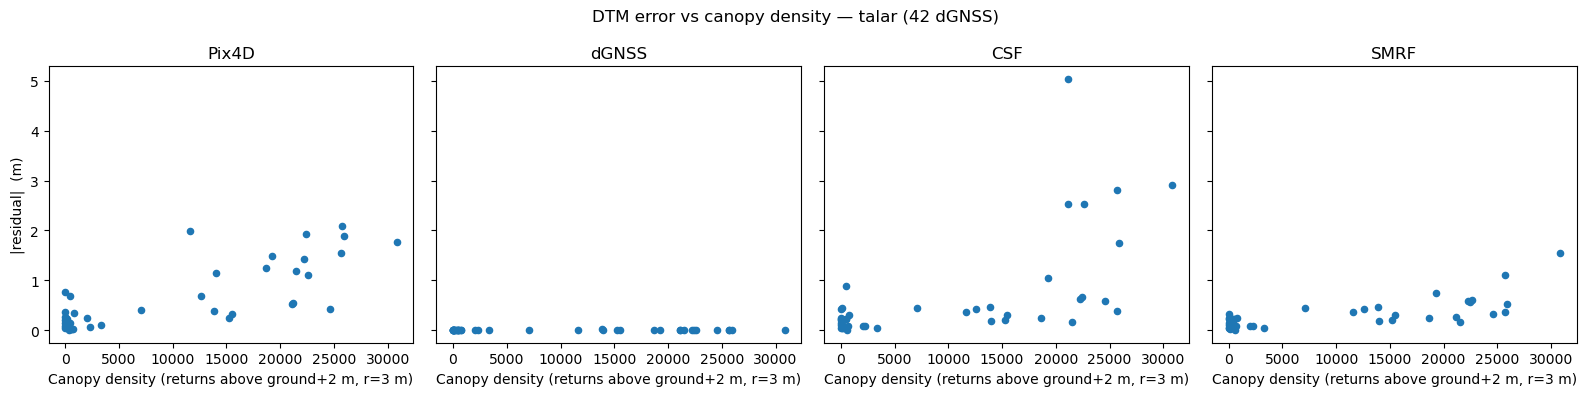

In [8]:
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4), sharey=True)
if len(samples) == 1:
    axes = [axes]
ref = puntos["Elevation"].to_numpy(dtype=float)
for ax, (label, pred) in zip(axes, samples.items()):
    resid = np.abs(pred - ref)
    ax.scatter(puntos["canopy_density"], resid, s=20)
    ax.set_xlabel("Canopy density (returns above ground+2 m, r=3 m)")
    ax.set_title(f"{label}")
axes[0].set_ylabel("|residual|  (m)")
fig.suptitle("DTM error vs canopy density — talar (42 dGNSS)")
fig.tight_layout()
fig.savefig(FIGS / "density_vs_residual.png", dpi=150)
fig.show()

C:\Users\paco_\AppData\Local\Temp\ipykernel_42288\59019116.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


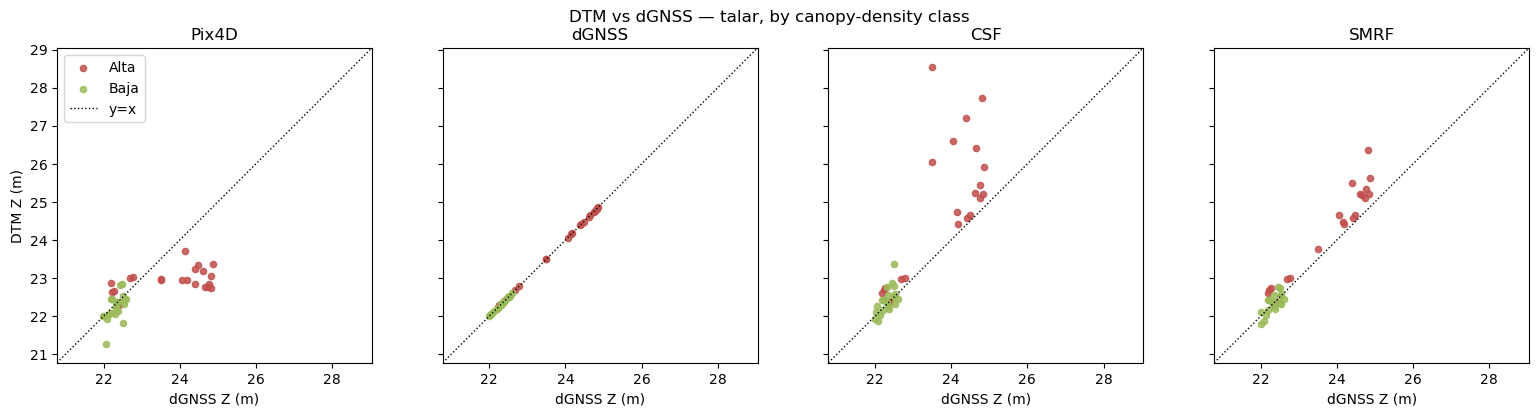

In [30]:
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4), sharex=True, sharey=True)
if len(samples) == 1:
    axes = [axes]
lo = min(ref.min(), min(np.nanmin(p) for p in samples.values())) - 0.5
hi = max(ref.max(), max(np.nanmax(p) for p in samples.values())) + 0.5
for ax, (label, pred) in zip(axes, samples.items()):
    for cls, color in [("Alta", "#c0504d"), ("Baja", "#9bbb59")]:
        mask = (puntos["density_class"] == cls).to_numpy()
        ax.scatter(ref[mask], pred[mask], label=cls, s=20, color=color, alpha=0.85)
    ax.plot([lo, hi], [lo, hi], "k:", lw=1, label="y=x")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("dGNSS Z (m)")
    ax.set_title(label)
    ax.set_aspect("equal", "box")
    # ax.vlines(x=25, ymin=0, ymax=hi)
axes[0].set_ylabel("DTM Z (m)")
axes[0].legend()
fig.suptitle("DTM vs dGNSS — talar, by canopy-density class")
fig.tight_layout()
fig.savefig(FIGS / "dtm_vs_dgnss_scatter.png", dpi=150)
fig.show()

In [10]:
# Persist the two summary tables for downstream notebooks / the report.
summary.to_csv(OUT / "validation_summary.csv")
stratified.to_csv(OUT / "validation_stratified.csv")
puntos.drop(columns="geometry").to_csv(OUT / "dgnss_with_density.csv", index=False)
print("Wrote:")
for p in [OUT / "validation_summary.csv", OUT / "validation_stratified.csv", OUT / "dgnss_with_density.csv"]:
    print(f"  {p}")

Wrote:
  c:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_summary.csv
  c:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\validation_stratified.csv
  c:\Users\paco_\OneDrive\Escritorio\repos\drone_reserve\outputs\02_dtm\dgnss_with_density.csv


## Notes

- The Pix4D row should reproduce the poster's table to two decimals on MAE and RMSE. R² will differ if the poster used Pearson² rather than the coefficient of determination — we use the latter, which is the standard for accuracy assessment.
- CSF / SMRF expected to outperform Pix4D-DTM in the Alta subset (this is the headline test). If they don't, retune `rigidness` / `window` and re-run.
- The continuous density figure is the new contribution: it shows where photogrammetry stops being trustworthy, instead of relying on a hand-drawn polygon.